# NOMB OASIM dataset

In [1]:
# imports
from importlib import reload
from importlib.resources import files
import os
import numpy as np

from scipy.optimize import curve_fit
import xarray

import pandas
import seaborn as sns
from matplotlib import pyplot as plt

from scipy.interpolate import interp1d

from oceancolor.hydrolight import loisel23
from oceancolor.utils import plotting as oc_plotting

from cnmf.oceanography import utils as co_utils
from cnmf import nmf_imaging

# Load up

In [2]:
nobm_file = os.path.join(os.getenv('OS_COLOR'), 'data', 'NOBM', 'all_NOBM_OASIM_data_2020.nc')

In [3]:
nobm_xds = xarray.open_dataset(nobm_file, decode_times=False)

In [4]:
nobm_xds

<xarray.Dataset>
Dimensions:         (months: 12, lat: 234, lon: 288, wavelength: 501)
Coordinates:
  * months          (months) float32 0.0 1.0 2.0 3.0 4.0 ... 8.0 9.0 10.0 11.0
  * lat             (lat) float32 -84.0 -83.33 -82.67 -82.0 ... 70.0 70.67 71.33
  * lon             (lon) float32 -180.0 -178.8 -177.5 ... 176.2 177.5 178.8
  * wavelength      (wavelength) int64 250 251 252 253 254 ... 747 748 749 750
Data variables: (12/41)
    tot             (months, lat, lon) float32 ...
    chl             (months, lat, lon) float32 ...
    dia             (months, lat, lon) float32 ...
    coc             (months, lat, lon) float32 ...
    cya             (months, lat, lon) float32 ...
    din             (months, lat, lon) float32 ...
    ...              ...
    coc_a           (wavelength, months, lat, lon) float32 ...
    coc_bb          (wavelength, months, lat, lon) float32 ...
    cdoc_a          (wavelength, months, lat, lon) float32 ...
    det_a           (wavelength, months, lat, lon) float32 ...
    det_bb          (wavelength, months, lat, lon) float32 ...
    pic_bb          (wavelength, months, lat, lon) float32 ...

In [15]:
wave = nobm_xds.wavelength.data

In [5]:
nobm_xds.lon

<xarray.DataArray 'lon' (lon: 288)>
array([-180.  , -178.75, -177.5 , ...,  176.25,  177.5 ,  178.75],
      dtype=float32)
Coordinates:
  * lon      (lon) float32 -180.0 -178.8 -177.5 -176.2 ... 176.2 177.5 178.8
Attributes:
    long_name:      longitude
    standard_name:  longitude
    units:          degrees_east
    valid_range:    [-180.  180.]

## Explore

In [6]:
rshape = nobm_xds.rrs.shape
rshape

(501, 12, 234, 288)

# Stack

In [7]:
nobm_stacked = nobm_xds.rrs.stack(z=("lat", "lon", "months"))

In [8]:
nobm_stacked.shape

(501, 808704)

## Remove the NaNs

In [9]:
nobm_stacked_no_nans = nobm_stacked.dropna(dim='z', how='all')

In [10]:
nobm_stacked_no_nans.shape

(501, 488364)

# Grab a random set of 50,000

In [11]:
Nspec = 50000
randi = np.random.choice(nobm_stacked_no_nans.shape[1], Nspec, replace=False)
randi

array([256013, 168270, 426325, ..., 363385, 238324,  93393])

## Grab em

In [12]:
r_rrs = nobm_stacked_no_nans.data[:, randi]

In [13]:
r_rrs.shape

(501, 50000)

# NMF me

## Scale

In [16]:
i350 = np.argmin(np.abs(wave-350.))

In [17]:
scaled_Rrs = (r_rrs.T * 1e4)[:,i350:]
cutwave = wave[i350:]

In [18]:
scaled_Rrs.shape

(50000, 401)

## Prep

In [19]:
new_spec, mask, err = co_utils.prep(scaled_Rrs, sigma=1.)

In [20]:
new_spec.shape

(50000, 401, 1)

## Check

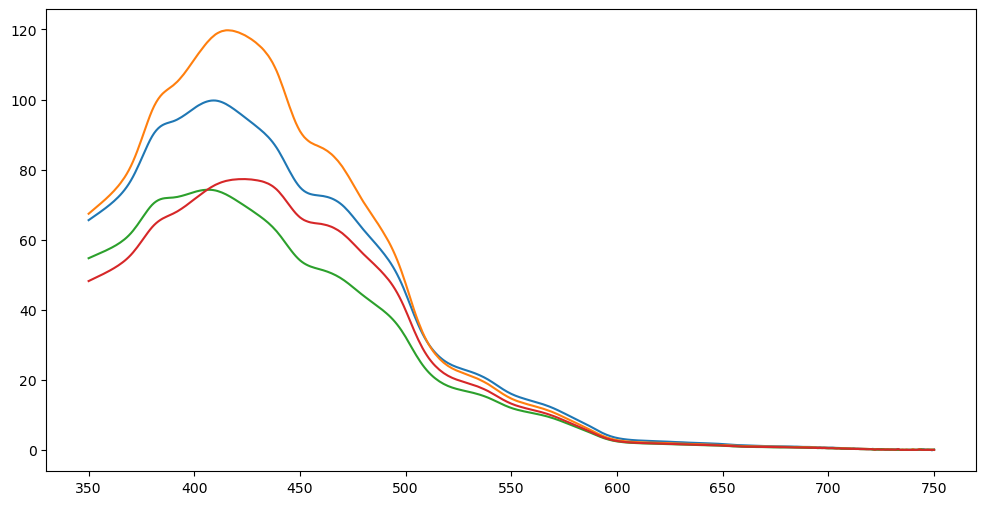

In [21]:
fig = plt.figure(figsize=(12,6))
ax = plt.gca()

ax.plot(cutwave, new_spec[0,:])
ax.plot(cutwave, new_spec[100,:])
ax.plot(cutwave, new_spec[1000,:])
ax.plot(cutwave, new_spec[10000,:])

if False:
    ii = 0
    sns.lineplot(x=cutwave, y=M[ii]*10000, color='k',
                 label=r'$W_'+f'{ii+1}'+'$',
                 ax=ax, lw=2)#

#
plt.show()


## Do it

## REMEMBER TO DELETE THE FILES FIRST!!!

### rm Anna_scaledRrs_co*

In [23]:
N_NMF = 4
outroot = 'Anna_scaledRrs'
normalize = True
#
comps = nmf_imaging.NMFcomponents(
    ref=new_spec, mask=mask, ref_err=err,
    n_components=N_NMF,
    path_save=outroot, oneByOne=True,
    normalize=normalize,
    seed=12345, verbose=True)

Building components one by one...
	 path_save provided, you might want to load data and continue previous component calculation
		 loading from Anna_scaledRrs_comp.npy for components.
		 Anna_scaledRrs_comp.npy does not exist, calculating from scratch.
	1 of 4
Current Chi2=9.6096, Previous Chi2=1984.8291, Change=99.5158% @ niters=0
Took 0.039 minutes to reach current solution.
			 Calculation for 1 components done, overwriting raw 2D component matrix at Anna_scaledRrs_comp.npy
			 Calculation for 1 components done, overwriting raw 2D coefficient matrix at Anna_scaledRrs_coef.npy
	2 of 4
Current Chi2=9.6406, Previous Chi2=9.6335, Change=-0.0737% @ niters=0
Took 0.012 minutes to reach current solution.
			 Calculation for 2 components done, overwriting raw 2D component matrix at Anna_scaledRrs_comp.npy
			 Calculation for 2 components done, overwriting raw 2D coefficient matrix at Anna_scaledRrs_coef.npy
	3 of 4
Current Chi2=9.6419, Previous Chi2=9.6236, Change=-0.1905% @ niters=0
Took 0

/home/xavier/Projects/Oceanography/python/cnmf/cnmf/nmf_imaging.py:397: RuntimeWarning: invalid value encountered in divide
  components = (components.T/np.sqrt(np.nansum(components**2, axis = (1, 2))).T).T


# Examine

In [58]:
M = np.load(outroot+'_comp.npy').T
coeff = np.load(outroot+'_coef.npy').T

In [59]:
M.shape

(4, 401)

## Plot

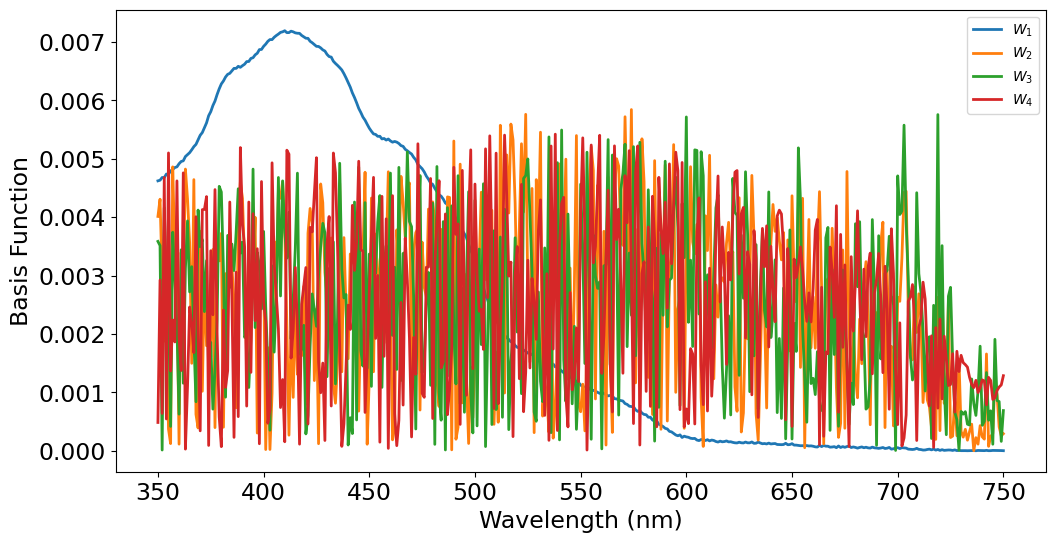

In [60]:
fig = plt.figure(figsize=(12,6))
ax = plt.gca()
#
for ii in range(N_NMF):
#for ii in range(1):
    # Step plot
    sns.lineplot(x=cutwave, y=M[ii],
                 label=r'$W_'+f'{ii+1}'+'$',
                 ax=ax, lw=2)#
# Pretty me up
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Basis Function')
oc_plotting.set_fontsize(ax, 17.)
#
plt.savefig('NMF_on_Rrs.png', dpi=300)
plt.show()